Goal: check if the PSFEx model can be approximated by Moffat in the NEA modeling.

__Conclusion: Nope.__

In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

from matplotlib.colors import LogNorm

Matplotlib created a temporary config/cache directory at /tmp/matplotlib-xpysvxcv because the default path (/homedir/.config/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
from tractor import *
from tractor.galaxy import *
from tractor.sersic import *

In [7]:
def get_sb_moffat(r, alpha, beta):
    """
    Calculate the surface brightness of light at radius r of a Moffat profile.
    The integral (i.e., total flux) is unity by definition.
    """
    i = (beta-1)/(np.pi * alpha**2)*(1 + (r/alpha)**2)**(-beta)
    return i

In [3]:
params = {'legend.fontsize': 'large',
          'axes.labelsize': 'large',
          'axes.titlesize': 'large',
          'xtick.labelsize': 'large',
          'ytick.labelsize': 'large',
          'figure.facecolor': 'w'}
plt.rcParams.update(params)

In [4]:
cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/dr10dev/misc/survey-ccds-dr10-v4-psfex-fwhm.fits'))
print(len(cat))
dr9 = Table(fitsio.read('/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/survey-ccds-decam-dr9.fits.gz', columns=['expnum', 'ccdname', 'ccd_cuts', 'filter']))
print(len(dr9))

cat['ccd_id_str'] = np.char.add(np.array(cat['expnum']).astype(str), cat['ccdname'])
dr9['ccd_id_str'] = np.char.add(np.array(dr9['expnum']).astype(str), dr9['ccdname'])

mask = dr9['ccd_cuts']==0
dr9 = dr9[mask]
print(len(dr9))

cat = join(cat, dr9[['ccd_id_str', 'filter']], keys='ccd_id_str', join_type='inner')
print(len(cat))

ccd = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/useful/survey-ccds-decam-dr9-trim.fits'))
cat = join(cat, ccd[['expnum', 'image_filename']])

cat_all = cat.copy()

15523579
6388340
4891222
4891222


In [5]:
mask = cat['ccdname']=='N10'
cat = cat[mask]

/global/cfs/projectdirs/cosmo/work/legacysurvey/dr9/calib/psfex/decam/CP/V4.8.2a/CP20190102/c4d_190103_015212_ooi_g_ls9-psfex.fits


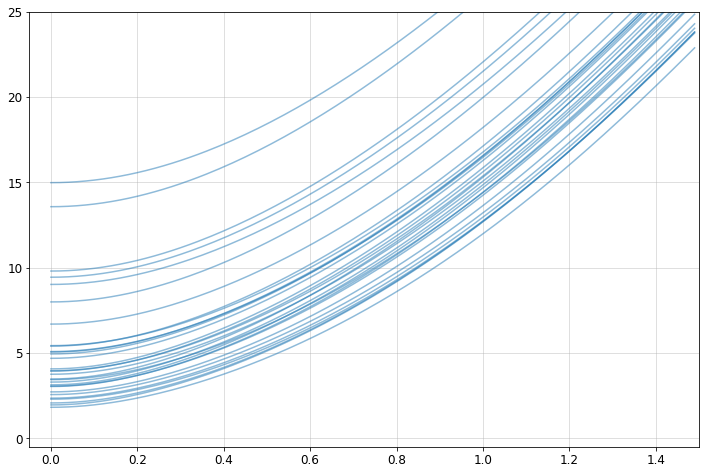

In [12]:
np.random.seed(929)
idx = np.random.choice(len(cat), size=30, replace=False)

plt.figure(figsize=(12, 8))

for index in idx:
    image_filename = cat['image_filename'][index]
    psfex_filename = image_filename[:image_filename.find('.fits.fz')]+'-psfex.fits'
    psfex_path = os.path.join('/global/cfs/projectdirs/cosmo/work/legacysurvey/dr9/calib/psfex', psfex_filename)
    if index==idx[0]:
        print(psfex_path)
    psfex = Table(fitsio.read(psfex_path))
    ii = np.where(psfex['ccdname']==cat['ccdname'][index])[0][0]
    psfex_img = np.array(psfex['psf_mask'][ii][0])
    psfex_img /= np.sum(psfex_img)
    
    W, H = 41, 41

    shape_r_list = np.arange(0., 1.5, 0.01)
    nea_list = []

    for shape_r in shape_r_list:

        psffwhm = 1.2 / 0.262
        psfsigma = psffwhm / 2.3548
        # print('psfsigma', psfsigma)

        tim = Image(data=np.zeros((H,W)), invvar=np.ones((H,W))/(0.01**2),
                    psf=PixelizedPSF(psfex_img))


        source = ExpGalaxy(PixPos(20, 20), Flux(1.), GalaxyShape(shape_r/0.262, 1, 45.))
        tractor = Tractor([tim], [source])

        mod = tractor.getModelImage(0)

        nea = np.sum(mod)**2/np.sum(mod**2) # in unit of number of pixels
        # print('NEA = {:.2f} ({:.2f} arcsec^2)'.format(nea, nea*0.262**2))
        nea_list.append(nea)

    shape_r_list = np.array(shape_r_list)
    nea_list = np.array(nea_list)

    plt.plot(shape_r_list, nea_list*0.262**2, color='C0', alpha=0.5)

plt.axis([-0.05, 1.5, -0.5, 25])
plt.grid(alpha=0.5)
plt.show()

/global/cfs/projectdirs/cosmo/work/legacysurvey/dr9/calib/psfex/decam/CP/V4.8.2a/CP20190102/c4d_190103_015212_ooi_g_ls9-psfex.fits
Sum:  1.000 1.000
FWHM: 5.921 5.572
Sum:  1.000 1.000
FWHM: 4.753 4.295
Sum:  1.000 1.000
FWHM: 4.709 4.168
Sum:  1.000 1.000
FWHM: 4.924 4.590
Sum:  1.000 1.000
FWHM: 4.448 3.861
Sum:  1.000 1.000
FWHM: 5.716 5.397
Sum:  1.000 1.000
FWHM: 3.553 2.967
Sum:  1.000 1.000
FWHM: 3.896 3.067
Sum:  1.000 1.000
FWHM: 5.730 5.419
Sum:  1.000 1.000
FWHM: 5.658 5.160
Sum:  1.000 1.000
FWHM: 9.401 9.364
Sum:  1.000 1.000
FWHM: 4.507 4.193
Sum:  1.000 1.000
FWHM: 7.977 7.829
Sum:  1.000 1.000
FWHM: 5.506 5.203
Sum:  1.000 1.000
FWHM: 7.196 6.955
Sum:  1.000 1.000
FWHM: 9.864 9.845
Sum:  1.000 1.000
FWHM: 6.573 6.381
Sum:  1.000 1.000
FWHM: 5.911 5.738
Sum:  1.000 1.000
FWHM: 4.618 4.473
Sum:  1.000 1.000
FWHM: 3.843 3.092
Sum:  1.000 1.000
FWHM: 5.054 4.608
Sum:  1.000 1.000
FWHM: 7.821 7.718
Sum:  1.000 1.000
FWHM: 3.421 2.298
Sum:  1.000 1.000
FWHM: 3.657 2.889
Sum: 

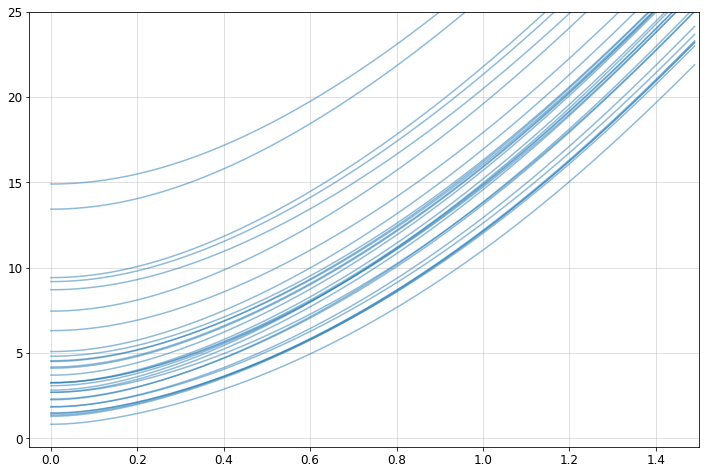

In [11]:
np.random.seed(929)
idx = np.random.choice(len(cat), size=30, replace=False)

plt.figure(figsize=(12, 8))

for index in idx:
    image_filename = cat['image_filename'][index]
    psfex_filename = image_filename[:image_filename.find('.fits.fz')]+'-psfex.fits'
    psfex_path = os.path.join('/global/cfs/projectdirs/cosmo/work/legacysurvey/dr9/calib/psfex', psfex_filename)
    if index==idx[0]:
        print(psfex_path)
    psfex = Table(fitsio.read(psfex_path))
    ii = np.where(psfex['ccdname']==cat['ccdname'][index])[0][0]
    psfex_img = np.array(psfex['psf_mask'][ii][0])
    psfex_img /= np.sum(psfex_img)
    
    psfex_nea = np.sum(psfex_img)**2/np.sum(psfex_img**2)
    psfex_fwhm = np.sqrt(psfex_nea / (4 * np.pi)) * 2.3548  # FWHM a la tractor
    
    img_size = 31
    pixscale = 0.262

    subpix_factor = 11
    x = pixscale * (np.arange(-img_size-0.5, img_size+0.5, 1/subpix_factor) + 1/subpix_factor/2)
    y = pixscale * (np.arange(-img_size-0.5, img_size+0.5, 1/subpix_factor) + 1/subpix_factor/2)
    xx, yy = np.meshgrid(x, y)
    rr = np.sqrt(xx**2+yy**2)

    alpha, beta = psfex['moffat_alpha'][ii], psfex['moffat_beta'][ii]
    moffat_img = pixscale**2 * get_sb_moffat(rr, alpha, beta)
    moffat_img = np.mean(np.mean(moffat_img.reshape((moffat_img.shape[0]//subpix_factor, subpix_factor, moffat_img.shape[1]//subpix_factor,-1)), axis=3), axis=1)
    moffat_img /= np.sum(moffat_img)
    print('Sum:  {:.3f} {:.3f}'.format(np.sum(moffat_img), np.sum(psfex_img)))
    moffat_nea = np.sum(moffat_img)**2/np.sum(moffat_img**2)
    moffat_fwhm = np.sqrt(moffat_nea / (4 * np.pi)) * 2.3548  # FWHM a la tractor
    print('FWHM: {:.3f} {:.3f}'.format(psfex_fwhm, moffat_fwhm))

    # fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    # ax[0].imshow(psfex_img, vmin=-0.02, vmax=0.02, cmap='seismic')
    # ax[0].set_title('PSFEx')
    # ax[1].imshow(moffat_img, vmin=-0.02, vmax=0.02, cmap='seismic')
    # ax[1].set_title('Moffat')
    # ax[2].imshow(psfex_img - moffat_img, vmin=-0.02, vmax=0.02, cmap='seismic')
    # ax[2].set_title('PSFEx - Moffat')
    # plt.show()

    W, H = 41, 41

    shape_r_list = np.arange(0., 1.5, 0.01)
    nea_list = []

    for shape_r in shape_r_list:

        psffwhm = 1.2 / 0.262
        psfsigma = psffwhm / 2.3548
        # print('psfsigma', psfsigma)

        tim = Image(data=np.zeros((H,W)), invvar=np.ones((H,W))/(0.01**2),
                    psf=PixelizedPSF(moffat_img))


        source = ExpGalaxy(PixPos(20, 20), Flux(1.), GalaxyShape(shape_r/0.262, 1, 45.))
        tractor = Tractor([tim], [source])

        mod = tractor.getModelImage(0)

        nea = np.sum(mod)**2/np.sum(mod**2) # in unit of number of pixels
        # print('NEA = {:.2f} ({:.2f} arcsec^2)'.format(nea, nea*0.262**2))
        nea_list.append(nea)

    shape_r_list = np.array(shape_r_list)
    nea_list = np.array(nea_list)

    plt.plot(shape_r_list, nea_list*0.262**2, color='C0', alpha=0.5)

plt.axis([-0.05, 1.5, -0.5, 25])
plt.grid(alpha=0.5)
plt.show()

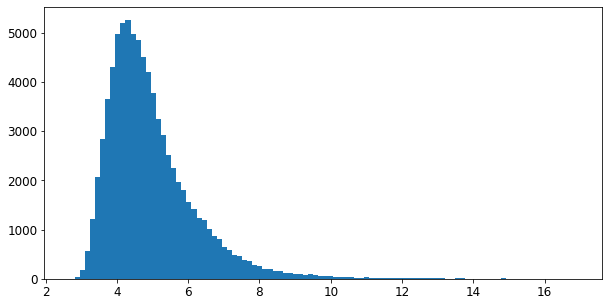

In [13]:
plt.figure(figsize=(10, 5))
plt.hist(cat['psf_fwhm'], 100)
plt.show()

138
/global/cfs/projectdirs/cosmo/work/legacysurvey/dr9/calib/psfex/decam/CP/V4.1/CP20171012/c4d_171013_043512_ooi_r_v1-psfex.fits


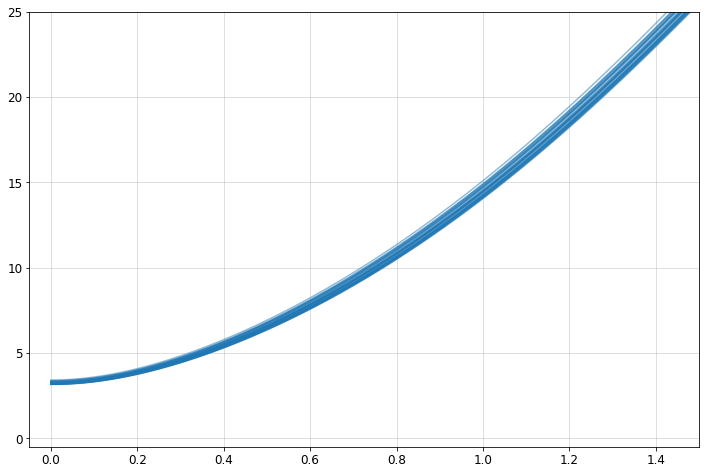

In [17]:
np.random.seed(929)
idx = np.where((cat['psf_fwhm']*0.262>1.199*0.96) & (cat['psf_fwhm']*0.262<1.2*0.96))[0]
print(len(idx))
idx = np.random.choice(idx, size=30, replace=False)

plt.figure(figsize=(12, 8))

for index in idx:
    image_filename = cat['image_filename'][index]
    psfex_filename = image_filename[:image_filename.find('.fits.fz')]+'-psfex.fits'
    psfex_path = os.path.join('/global/cfs/projectdirs/cosmo/work/legacysurvey/dr9/calib/psfex', psfex_filename)
    if index==idx[0]:
        print(psfex_path)
    psfex = Table(fitsio.read(psfex_path))
    ii = np.where(psfex['ccdname']==cat['ccdname'][index])[0][0]
    psfex_img = np.array(psfex['psf_mask'][ii][0])
    psfex_img /= np.sum(psfex_img)
    
    psfex_nea = np.sum(psfex_img)**2/np.sum(psfex_img**2)
    psfex_fwhm = np.sqrt(psfex_nea / (4 * np.pi)) * 2.3548  # FWHM a la tractor

    W, H = 41, 41

    shape_r_list = np.arange(0., 1.5, 0.01)
    nea_list = []

    for shape_r in shape_r_list:

        psffwhm = 1.2 / 0.262
        psfsigma = psffwhm / 2.3548
        # print('psfsigma', psfsigma)

        tim = Image(data=np.zeros((H,W)), invvar=np.ones((H,W))/(0.01**2),
                    psf=PixelizedPSF(psfex_img))


        source = ExpGalaxy(PixPos(20, 20), Flux(1.), GalaxyShape(shape_r/0.262, 1, 45.))
        tractor = Tractor([tim], [source])

        mod = tractor.getModelImage(0)

        nea = np.sum(mod)**2/np.sum(mod**2) # in unit of number of pixels
        # print('NEA = {:.2f} ({:.2f} arcsec^2)'.format(nea, nea*0.262**2))
        nea_list.append(nea)

    shape_r_list = np.array(shape_r_list)
    nea_list = np.array(nea_list)

    plt.plot(shape_r_list, nea_list*0.262**2, color='C0', alpha=0.5)

plt.axis([-0.05, 1.5, -0.5, 25])
plt.grid(alpha=0.5)
plt.show()

138
/global/cfs/projectdirs/cosmo/work/legacysurvey/dr9/calib/psfex/decam/CP/V4.1/CP20171012/c4d_171013_043512_ooi_r_v1-psfex.fits
Sum:  1.000 1.000
FWHM: 4.555 4.096
Sum:  1.000 1.000
FWHM: 4.543 3.855
Sum:  1.000 1.000
FWHM: 4.587 4.244
Sum:  1.000 1.000
FWHM: 4.583 4.096
Sum:  1.000 1.000
FWHM: 4.560 4.176
Sum:  1.000 1.000
FWHM: 4.561 3.987
Sum:  1.000 1.000
FWHM: 4.597 3.957
Sum:  1.000 1.000
FWHM: 4.588 4.080
Sum:  1.000 1.000
FWHM: 4.527 4.002
Sum:  1.000 1.000
FWHM: 4.533 4.233
Sum:  1.000 1.000
FWHM: 4.568 4.243
Sum:  1.000 1.000
FWHM: 4.708 4.038
Sum:  1.000 1.000
FWHM: 4.643 4.043
Sum:  1.000 1.000
FWHM: 4.527 4.039
Sum:  1.000 1.000
FWHM: 4.559 4.202
Sum:  1.000 1.000
FWHM: 4.644 4.193
Sum:  1.000 1.000
FWHM: 4.546 4.007
Sum:  1.000 1.000
FWHM: 4.628 4.195
Sum:  1.000 1.000
FWHM: 4.659 4.391
Sum:  1.000 1.000
FWHM: 4.589 4.155
Sum:  1.000 1.000
FWHM: 4.564 4.110
Sum:  1.000 1.000
FWHM: 4.581 4.548
Sum:  1.000 1.000
FWHM: 4.551 4.114
Sum:  1.000 1.000
FWHM: 4.508 4.112
Sum: 

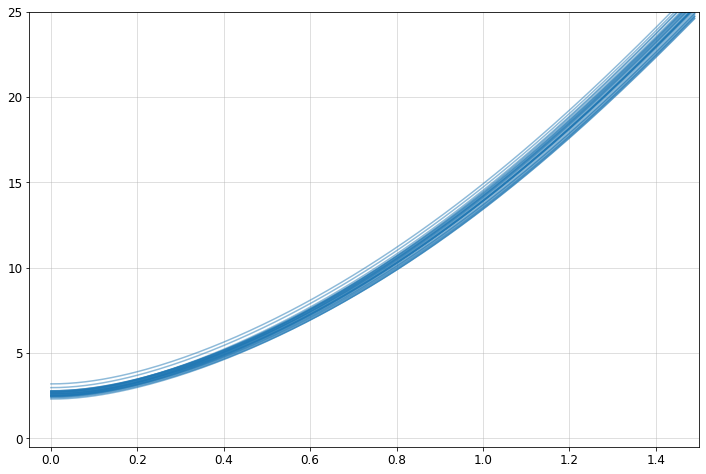

In [19]:
np.random.seed(929)
idx = np.where((cat['psf_fwhm']*0.262>1.199*0.96) & (cat['psf_fwhm']*0.262<1.2*0.96))[0]
print(len(idx))
idx = np.random.choice(idx, size=30, replace=False)

plt.figure(figsize=(12, 8))

for index in idx:
    image_filename = cat['image_filename'][index]
    psfex_filename = image_filename[:image_filename.find('.fits.fz')]+'-psfex.fits'
    psfex_path = os.path.join('/global/cfs/projectdirs/cosmo/work/legacysurvey/dr9/calib/psfex', psfex_filename)
    if index==idx[0]:
        print(psfex_path)
    psfex = Table(fitsio.read(psfex_path))
    ii = np.where(psfex['ccdname']==cat['ccdname'][index])[0][0]
    psfex_img = np.array(psfex['psf_mask'][ii][0])
    psfex_img /= np.sum(psfex_img)
    
    psfex_nea = np.sum(psfex_img)**2/np.sum(psfex_img**2)
    psfex_fwhm = np.sqrt(psfex_nea / (4 * np.pi)) * 2.3548  # FWHM a la tractor

    img_size = 31
    pixscale = 0.262

    subpix_factor = 11
    x = pixscale * (np.arange(-img_size-0.5, img_size+0.5, 1/subpix_factor) + 1/subpix_factor/2)
    y = pixscale * (np.arange(-img_size-0.5, img_size+0.5, 1/subpix_factor) + 1/subpix_factor/2)
    xx, yy = np.meshgrid(x, y)
    rr = np.sqrt(xx**2+yy**2)

    alpha, beta = psfex['moffat_alpha'][ii], psfex['moffat_beta'][ii]
    moffat_img = pixscale**2 * get_sb_moffat(rr, alpha, beta)
    moffat_img = np.mean(np.mean(moffat_img.reshape((moffat_img.shape[0]//subpix_factor, subpix_factor, moffat_img.shape[1]//subpix_factor,-1)), axis=3), axis=1)
    moffat_img /= np.sum(moffat_img)
    print('Sum:  {:.3f} {:.3f}'.format(np.sum(moffat_img), np.sum(psfex_img)))
    moffat_nea = np.sum(moffat_img)**2/np.sum(moffat_img**2)
    moffat_fwhm = np.sqrt(moffat_nea / (4 * np.pi)) * 2.3548  # FWHM a la tractor
    print('FWHM: {:.3f} {:.3f}'.format(psfex_fwhm, moffat_fwhm))

    W, H = 41, 41

    shape_r_list = np.arange(0., 1.5, 0.01)
    nea_list = []

    for shape_r in shape_r_list:

        psffwhm = 1.2 / 0.262
        psfsigma = psffwhm / 2.3548
        # print('psfsigma', psfsigma)

        tim = Image(data=np.zeros((H,W)), invvar=np.ones((H,W))/(0.01**2),
                    psf=PixelizedPSF(moffat_img))


        source = ExpGalaxy(PixPos(20, 20), Flux(1.), GalaxyShape(shape_r/0.262, 1, 45.))
        tractor = Tractor([tim], [source])

        mod = tractor.getModelImage(0)

        nea = np.sum(mod)**2/np.sum(mod**2) # in unit of number of pixels
        # print('NEA = {:.2f} ({:.2f} arcsec^2)'.format(nea, nea*0.262**2))
        nea_list.append(nea)

    shape_r_list = np.array(shape_r_list)
    nea_list = np.array(nea_list)

    plt.plot(shape_r_list, nea_list*0.262**2, color='C0', alpha=0.5)

plt.axis([-0.05, 1.5, -0.5, 25])
plt.grid(alpha=0.5)
plt.show()